In [135]:
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema
from scipy.signal import find_peaks
from itertools import product
from tqdm import tqdm
import time
import numba as nb
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import talib as ta
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [136]:
df=pd.read_csv('../../all_data_EUR_USD.csv')

In [137]:
df.set_index('time',inplace=True)

In [138]:
df['RSI_low']=ta.RSI(df['l'],14)

In [139]:
df['RSI_high']=ta.RSI(df['h'],14)

In [140]:
df_test=df.copy()

In [141]:
df_test

,o,h,l,c,volume,complete,RSI_low,RSI_high
time,,,,,,,,
2005-01-02 18:15:00,1.35600,1.35600,1.35600,1.35600,1,True,NaN,NaN
2005-01-02 18:30:00,1.35600,1.35600,1.35600,1.35600,1,True,NaN,NaN
2005-01-02 18:45:00,1.35670,1.35680,1.35650,1.35670,4,True,NaN,NaN
2005-01-02 19:00:00,1.35690,1.35700,1.35690,1.35690,5,True,NaN,NaN
2005-01-02 19:15:00,1.35650,1.35690,1.35560,1.35560,27,True,NaN,NaN
...,...,...,...,...,...,...,...,...
2023-03-03 20:45:00,1.06330,1.06352,1.06306,1.06352,983,True,63.803688,62.389285
2023-03-03 21:00:00,1.06350,1.06351,1.06325,1.06342,343,True,65.473977,62.211278
2023-03-03 21:15:00,1.06346,1.06346,1.06321,1.06322,212,True,64.796074,61.269974


In [142]:
def calc_low_points(low_vals):

    temp_min=low_vals[0]
    

    for i in range(len(low_vals)):

         if low_vals[i]<temp_min:

             temp_min=low_vals[i]


        

    if temp_min==low_vals[-2]:

       return low_vals[-2]

    else:

        return -1

In [143]:
def calc_high_points(high_vals):

    temp_max=high_vals[0]
    

    for i in range(len(high_vals)):

         if high_vals[i]>temp_max:

             temp_max=high_vals[i]


        

    if temp_max==high_vals[-2]:

       return high_vals[-2]

    else:

        return 101

In [144]:
def find_ll(rsi):


    temp_min=-1
   

    for i in range(len(rsi) - 2, -1, -1):
        if rsi[i]!=-1:
       
            if rsi[i]<rsi[-1]:
    
                temp_min=rsi[i]
                
                break

               
    
    return temp_min

In [145]:
def find_hh(rsi):

    temp_max=101

    for i in range(len(rsi) - 2, -1, -1):
        if rsi[i]!=101:
       
            if rsi[i]>rsi[-1]:
    
                temp_max=rsi[i]
                
                break

               
    
    return temp_max

In [146]:
def find_ll_idx(rsi):

    
    last_min_idx=0

    for i in range(len(rsi) - 2, -1, -1):
        if rsi[i]!=-1:
        
            if rsi[i]<rsi[-1]:
    
                
                last_min_idx=i-1
                break

               
    
    return last_min_idx

In [147]:
def find_hh_idx(rsi):

    
    last_max_idx=0

    for i in range(len(rsi) - 2, -1, -1):
        if rsi[i]!=101:
        
            if rsi[i]>rsi[-1]:
        
                
                last_max_idx=i-1
                break

               
    
    return last_max_idx

In [161]:
class RSI_divergence():

    def __init__(self, data):

        self.data=data

        self.params_range={'RSI_low_window':[10,14,20,28],
                           'RSI_high_window':[10,14,20,28],
                          'lookback':[15,23,36,57,91]}
                          


        self.possible_strats={'strategy_desc':'Strategy RSI divergence',
                              'div_point':{'name':'detect divergence RSI points',
                                          'positions':{'buy':'bull point',
                                                       'sell':'bear point'},
                                            'pos_columns':{}}}

        
    def create_params_combs(self):

        return list(product(*self.params_range.values()))

    def calc_indicator(self, RSI_low_window,RSI_high_window, lookback):


        self.rsi_low_window=RSI_low_window
        self.rsi_high_window=RSI_high_window
        self.lookback=lookback

        df=self.data.copy()
        

            
        df['RSI_high']=ta.RSI(df['h'],RSI_high_window)
        df['RSI_low']=ta.RSI(df['l'],RSI_low_window)

        

       

             

        
        
        df['ll']=df['RSI_low'].rolling(3).apply(calc_low_points, raw=True, engine='numba')
        df['hh']=df['RSI_high'].rolling(3).apply(calc_high_points, raw=True, engine='numba')

     

        df['idx']=range(len(df))

        df['last_min']=df['ll'].rolling(lookback).apply(find_ll, raw=True, engine='numba')
        df['last_max']=df['hh'].rolling(lookback).apply(find_hh, raw=True, engine='numba')

        df['prev_min_idx']=df['ll'].rolling(lookback).apply(find_ll_idx, raw=True, engine='numba')+df.idx-lookback+1
        df['prev_max_idx']=df['hh'].rolling(lookback).apply(find_hh_idx, raw=True, engine='numba')+df.idx-lookback+1
        df['last_min_idx']=np.where((df['ll']!=-1)&(df['last_min']!=-1)&(df['ll'].notna()), df['idx'].shift(),0)
        df['last_max_idx']=np.where((df['hh']!=101)&(df['last_max']!=101)&(df['hh'].notna()), df['idx'].shift(),0)
        df['last_min_price']=np.where((df['ll']!=-1)&(df['last_min']!=-1)&(df['ll'].notna()), df['l'].shift(),0)
        df['last_max_price']=np.where((df['hh']!=101)&(df['last_max']!=101)&(df['hh'].notna()), df['h'].shift(),0)

        prev_min_prices_idx=np.array(df['prev_min_idx'])
        prev_max_prices_idx=np.array(df['prev_max_idx'])
        prev_min_prices=np.array(df['l'].iloc[np.nan_to_num(prev_min_prices_idx)])
        prev_max_prices=np.array(df['h'].iloc[np.nan_to_num(prev_max_prices_idx)])
        df['prev_min_prices']=prev_min_prices
        df['prev_max_prices']=prev_max_prices

        self.data=df.copy()

    def calc_position(self):

        df=self.data.copy()

        self.pos_ch_colname=f'pos_ch_div_point_rlw_{self.rsi_low_window}_rhw_{self.rsi_high_window}_lb_{self.lookback}'
        self.pos_colname=f'pos_div_point_rlw_{self.rsi_low_window}_rhw_{self.rsi_high_window}_lb_{self.lookback}'

        cond_buy_check=(df['ll']!=-1)&(df['last_min']!=-1)&(df['prev_min_idx'].notna())
        cond_buy_price=(df['last_min_price']!=0)&(df['prev_min_prices']>df['last_min_price'])
        cond_sell_check=(df['hh']!=101)&(df['last_max']!=101)&(df['prev_max_idx'].notna())
        cond_sell_price=(df['last_max_price']!=0)&(df['prev_max_prices']<df['last_max_price'])

        df[f'{self.pos_ch_colname}']=np.nan
        df[f'{self.pos_ch_colname}']=np.where(cond_buy_check&cond_buy_price,1,df[f'{self.pos_ch_colname}'])
        df[f'{self.pos_ch_colname}']=np.where(cond_sell_check&cond_sell_price,-1,df[f'{self.pos_ch_colname}'])
        df[f'{self.pos_colname}']= df[f'{self.pos_ch_colname}'].ffill()
        df[f'{self.pos_ch_colname}']=df[f'{self.pos_ch_colname}'].fillna(0)
        df[f'{self.pos_colname}']= df[f'{self.pos_colname}'].fillna(0)
        
        

        self.data=df[[col for col in df.columns if col not in ['ll','hh','idx','last_min',
                                                              'last_max','prev_min_idx','prev_max_idx','last_min_idx','last_max_idx','last_min_price','last_max_price',
                                                              'prev_min_prices','prev_max_prices']]]

        


In [162]:
rsid=RSI_divergence(df_test)

In [163]:
cmb=rsid.create_params_combs()

In [164]:
cmb

[(10, 10, 15),
 (10, 10, 23),
 (10, 10, 36),
 (10, 10, 57),
 (10, 10, 91),
 (10, 14, 15),
 (10, 14, 23),
 (10, 14, 36),
 (10, 14, 57),
 (10, 14, 91),
 (10, 20, 15),
 (10, 20, 23),
 (10, 20, 36),
 (10, 20, 57),
 (10, 20, 91),
 (10, 28, 15),
 (10, 28, 23),
 (10, 28, 36),
 (10, 28, 57),
 (10, 28, 91),
 (14, 10, 15),
 (14, 10, 23),
 (14, 10, 36),
 (14, 10, 57),
 (14, 10, 91),
 (14, 14, 15),
 (14, 14, 23),
 (14, 14, 36),
 (14, 14, 57),
 (14, 14, 91),
 (14, 20, 15),
 (14, 20, 23),
 (14, 20, 36),
 (14, 20, 57),
 (14, 20, 91),
 (14, 28, 15),
 (14, 28, 23),
 (14, 28, 36),
 (14, 28, 57),
 (14, 28, 91),
 (20, 10, 15),
 (20, 10, 23),
 (20, 10, 36),
 (20, 10, 57),
 (20, 10, 91),
 (20, 14, 15),
 (20, 14, 23),
 (20, 14, 36),
 (20, 14, 57),
 (20, 14, 91),
 (20, 20, 15),
 (20, 20, 23),
 (20, 20, 36),
 (20, 20, 57),
 (20, 20, 91),
 (20, 28, 15),
 (20, 28, 23),
 (20, 28, 36),
 (20, 28, 57),
 (20, 28, 91),
 (28, 10, 15),
 (28, 10, 23),
 (28, 10, 36),
 (28, 10, 57),
 (28, 10, 91),
 (28, 14, 15),
 (28, 14, 

In [165]:
#rsid.calc_indicator(14,14,100)

In [166]:
#rsid.data

In [167]:
#rsid.data[:50].loc[:,['idx','h','RSI_high','hh','last_max','last_max_idx','prev_max_idx']]#,'last_max_price','prev_max_prices']]

In [168]:
#rsid.data[50:100].loc[:,['idx','h','hh','last_max','last_max_idx','prev_max_idx']]#,'last_max_price','prev_max_prices']]

In [169]:
#rsid.calc_position()

In [170]:
#rsid.data[50:100]

In [171]:
#rsid.data['pos_ch_div_point_rlw_14_rhw_14_lb_100'].value_counts()

In [172]:
#rsid.data[50:100]

In [173]:
for c in tqdm(cmb):

    

    rsid.calc_indicator(*c)
    
    rsid.calc_position()
    

100%|██████████| 80/80 [03:08<00:00,  2.35s/it]


In [129]:
#rsid.data.iloc[100:150].loc[:,['o', 'h', 'l', 'c', 'volume', 'complete', 'RSI_low', 'RSI_high','pos_ch_div_point_rlw_14_rhw_14_lb_46','pos_ch_div_point_rlw_14_rhw_14_lb_67']]

In [178]:
for c in rsid.data.columns:

    if 'pos_ch' in c:

        print(rsid.data[c].value_counts())

pos_ch_div_point_rlw_10_rhw_10_lb_15
 0.0    414745
 1.0      9093
-1.0      8934
Name: count, dtype: int64
pos_ch_div_point_rlw_10_rhw_10_lb_23
 0.0    411870
 1.0     10468
-1.0     10434
Name: count, dtype: int64
pos_ch_div_point_rlw_10_rhw_10_lb_36
 0.0    409573
 1.0     11627
-1.0     11572
Name: count, dtype: int64
pos_ch_div_point_rlw_10_rhw_10_lb_57
 0.0    408081
 1.0     12379
-1.0     12312
Name: count, dtype: int64
pos_ch_div_point_rlw_10_rhw_10_lb_91
 0.0    406711
 1.0     13058
-1.0     13003
Name: count, dtype: int64
pos_ch_div_point_rlw_10_rhw_14_lb_15
 0.0    415789
 1.0      9096
-1.0      7887
Name: count, dtype: int64
pos_ch_div_point_rlw_10_rhw_14_lb_23
 0.0    413028
 1.0     10472
-1.0      9272
Name: count, dtype: int64
pos_ch_div_point_rlw_10_rhw_14_lb_36
 0.0    410825
 1.0     11630
-1.0     10317
Name: count, dtype: int64
pos_ch_div_point_rlw_10_rhw_14_lb_57
 0.0    409375
 1.0     12382
-1.0     11015
Name: count, dtype: int64
pos_ch_div_point_rlw_10_rhw_

In [175]:
rsid.data.to_csv('RSI_divergence_data.csv')

In [179]:
with open('rsi_divergence.json', "w") as f:
    json.dump(rsid.possible_strats, f)

In [130]:
df_plot=rsid.data.copy()

In [131]:
df_plot.columns

Index(['o', 'h', 'l', 'c', 'volume', 'complete', 'RSI_low', 'RSI_high',
       'pos_ch_div_point_rlw_14_rhw_14_lb_100',
       'pos_div_point_rlw_14_rhw_14_lb_100',
       ...
       'pos_ch_div_point_rlw_28_rhw_20_lb_67',
       'pos_div_point_rlw_28_rhw_20_lb_67',
       'pos_ch_div_point_rlw_28_rhw_28_lb_15',
       'pos_div_point_rlw_28_rhw_28_lb_15',
       'pos_ch_div_point_rlw_28_rhw_28_lb_23',
       'pos_div_point_rlw_28_rhw_28_lb_23',
       'pos_ch_div_point_rlw_28_rhw_28_lb_46',
       'pos_div_point_rlw_28_rhw_28_lb_46',
       'pos_ch_div_point_rlw_28_rhw_28_lb_67',
       'pos_div_point_rlw_28_rhw_28_lb_67'],
      dtype='object', length=138)

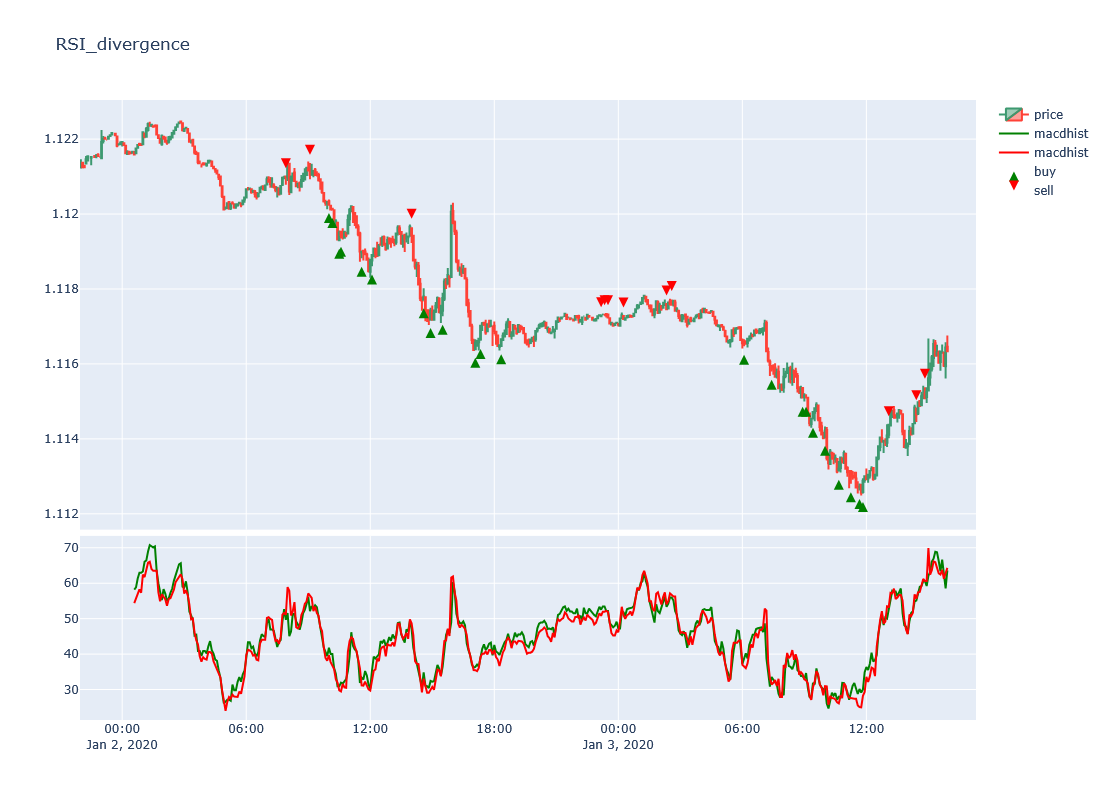

In [132]:
figure = make_subplots(rows=2, cols=1, row_heights=[0.7,0.3], shared_xaxes=True,vertical_spacing=0.01)
figure.update_layout(height=800, width=1200, title_text='RSI_divergence')

pos_col='pos_ch_div_point_rlw_14_rhw_14_lb_100'

y_color_buy=df_plot[df_plot[pos_col]==1]['l']*0.9998
y_color_buy_index=df_plot[df_plot[pos_col]==1].index
y_color_sell=df_plot[df_plot[pos_col]==-1]['h']*1.0002
y_color_sell_index=df_plot[df_plot[pos_col]==-1].index

#y_color_sell=df_plot[df_plot['pos_ch_bear']==-1]['h']*1.0002
#y_color_sell_index=df_plot[df_plot['pos_ch_bear']==-1].index
#y_color_buy=df_plot[df_plot['pos_ch_bull']==1]['l']*0.9998
#y_color_buy_index=df_plot[df_plot['pos_ch_bull']==1].index


figure.add_trace(go.Candlestick(x=df_plot.index,
                                open=df_plot['o'],
                                high=df_plot['h'],
                                low=df_plot['l'],
                                close=df_plot['c'],
                                name='price'), row=1, col=1)

figure.add_trace(go.Scatter(x=df_plot.index,y=df_plot['RSI_low'],mode='lines',line_color='green',name='macdhist'),col=1,row=2)
figure.add_trace(go.Scatter(x=df_plot.index,y=df_plot['RSI_high'],mode='lines',line_color='red',name='macdhist'),col=1,row=2)
figure.add_trace(go.Scatter(x=y_color_buy_index, y=y_color_buy, mode='markers', marker_symbol='arrow-up', marker_color='green', name='buy', marker_size=10), col=1, row=1)
figure.add_trace(go.Scatter(x=y_color_sell_index, y=y_color_sell, mode='markers', marker_symbol='arrow-down', marker_color='red', name='sell', marker_size=10), col=1, row=1)
#for i in idxs:
    

    #figure.add_trace(go.Scatter(x=df_plot.loc[i].index,y=df_plot['RSI_low'].loc[i],mode='lines',line_color='red',name='macdhist'),col=1,row=2)

    

figure.update_layout(xaxis_rangeslider_visible=False)
figure.update_xaxes(
        rangebreaks=[
            dict(bounds=["sat", "mon"])]
    )
figure.show()

In [106]:
df_plot

,o,h,l,c,volume,complete,RSI_low,RSI_high,RSI,pos_ch_div_point_rlw_14_rhw_14_lb_100,pos_div_point_rlw_14_rhw_14_lb_100
time,,,,,,,,,,,
2020-01-01 22:00:00+00:00,1.12124,1.12146,1.12124,1.12132,9,True,NaN,NaN,NaN,0.0,0.0
2020-01-01 22:05:00+00:00,1.12137,1.12137,1.12125,1.12125,5,True,NaN,NaN,NaN,0.0,0.0
2020-01-01 22:10:00+00:00,1.12129,1.12129,1.12125,1.12125,2,True,NaN,NaN,NaN,0.0,0.0
2020-01-01 22:15:00+00:00,1.12135,1.12155,1.12134,1.12146,12,True,NaN,NaN,NaN,0.0,0.0
2020-01-01 22:20:00+00:00,1.12143,1.12154,1.12143,1.12154,4,True,NaN,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2020-01-03 15:35:00+00:00,1.11605,1.11633,1.11582,1.11633,86,True,68.009867,65.306629,68.607205,0.0,-1.0
2020-01-03 15:40:00+00:00,1.11630,1.11652,1.11628,1.11632,78,True,73.406046,67.428104,68.374331,0.0,-1.0
2020-01-03 15:45:00+00:00,1.11630,1.11630,1.11592,1.11596,88,True,64.269085,62.650913,60.422994,0.0,-1.0


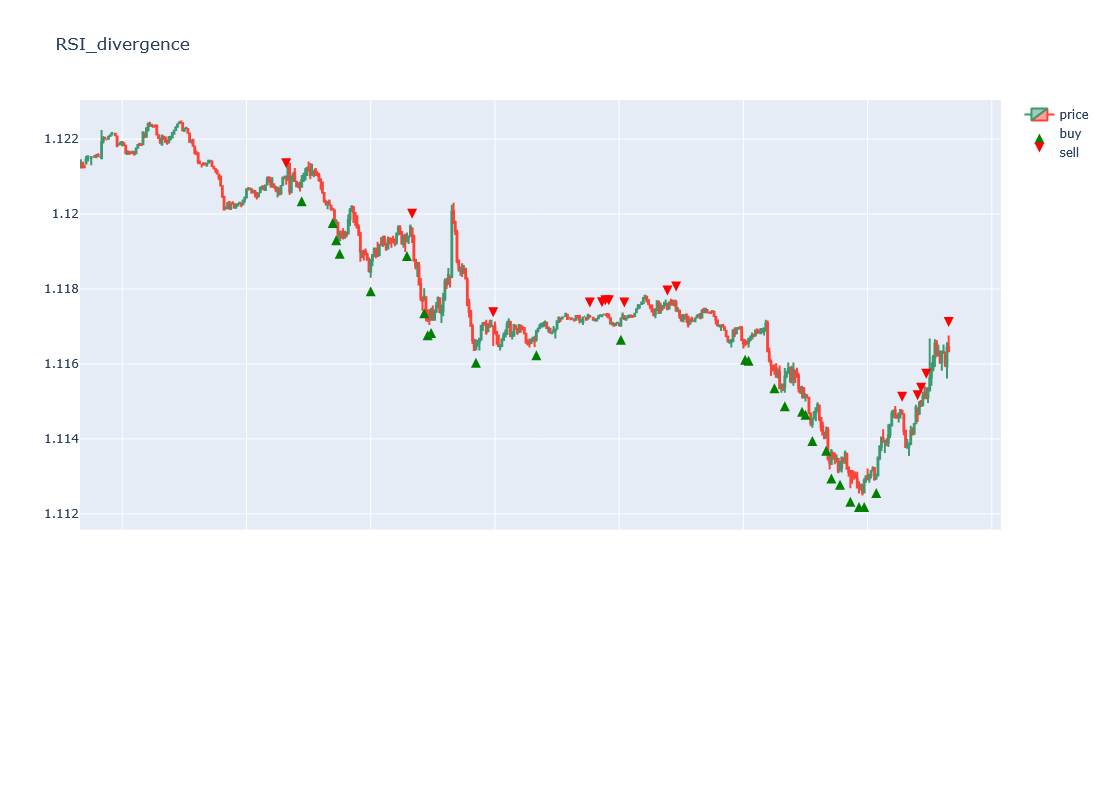

In [107]:
figure = make_subplots(rows=2, cols=1, row_heights=[0.7,0.3], shared_xaxes=True,vertical_spacing=0.01)
figure.update_layout(height=800, width=1200, title_text='RSI_divergence')

pos_col='pos_ch_div_point_rlw_14_rhw_14_lb_100'

y_color_buy=df_plot[df_plot[pos_col]==1]['l']*0.9998
y_color_buy_index=df_plot[df_plot[pos_col]==1].index
y_color_sell=df_plot[df_plot[pos_col]==-1]['h']*1.0002
y_color_sell_index=df_plot[df_plot[pos_col]==-1].index

#y_color_sell=df_plot[df_plot['pos_ch_bear']==-1]['h']*1.0002
#y_color_sell_index=df_plot[df_plot['pos_ch_bear']==-1].index
#y_color_buy=df_plot[df_plot['pos_ch_bull']==1]['l']*0.9998
#y_color_buy_index=df_plot[df_plot['pos_ch_bull']==1].index


figure.add_trace(go.Candlestick(x=df_plot.index,
                                open=df_plot['o'],
                                high=df_plot['h'],
                                low=df_plot['l'],
                                close=df_plot['c'],
                                name='price'), row=1, col=1)

#figure.add_trace(go.Scatter(x=df_plot.index,y=df_plot['RSI_low'],mode='lines',line_color='green',name='macdhist'),col=1,row=2)
#figure.add_trace(go.Scatter(x=df_plot.index,y=df_plot['RSI_high'],mode='lines',line_color='red',name='macdhist'),col=1,row=2)
figure.add_trace(go.Scatter(x=y_color_buy_index, y=y_color_buy, mode='markers', marker_symbol='arrow-up', marker_color='green', name='buy', marker_size=10), col=1, row=1)
figure.add_trace(go.Scatter(x=y_color_sell_index, y=y_color_sell, mode='markers', marker_symbol='arrow-down', marker_color='red', name='sell', marker_size=10), col=1, row=1)
#for i in idxs:
    

    #figure.add_trace(go.Scatter(x=df_plot.loc[i].index,y=df_plot['RSI_low'].loc[i],mode='lines',line_color='red',name='macdhist'),col=1,row=2)

    

figure.update_layout(xaxis_rangeslider_visible=False)
figure.update_xaxes(
        rangebreaks=[
            dict(bounds=["sat", "mon"])]
    )
figure.show()